In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [58]:
df = pd.read_csv("car data.csv")
print("First 5 Rows:\n", df.head())


First 5 Rows:
   Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [30]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [31]:
df.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Driven_kms,0
Fuel_Type,0
Selling_type,0
Transmission,0
Owner,0


In [59]:
df.drop("Car_Name", axis=1, inplace=True)
df = pd.get_dummies(df, drop_first=True)
df.head()

,Year,Selling_Price,Present_Price,Driven_kms,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,2014,3.35,5.59,27000,0,False,True,False,True
1,2013,4.75,9.54,43000,0,True,False,False,True
2,2017,7.25,9.85,6900,0,False,True,False,True
3,2011,2.85,4.15,5200,0,False,True,False,True
4,2014,4.60,6.87,42450,0,True,False,False,True


In [35]:
df['Car_Age'] = 2024 - df['Year']
df.drop("Year", axis=1, inplace=True)
print(df.head())

   Selling_Price  Present_Price  Driven_kms  Owner  Fuel_Type_Diesel  \
0           3.35           5.59       27000      0             False   
1           4.75           9.54       43000      0              True   
2           7.25           9.85        6900      0             False   
3           2.85           4.15        5200      0             False   
4           4.60           6.87       42450      0              True   

   Fuel_Type_Petrol  Selling_type_Individual  Transmission_Manual  Car_Age  
0              True                    False                 True       10  
1             False                    False                 True       11  
2              True                    False                 True        7  
3              True                    False                 True       13  
4             False                    False                 True       10  


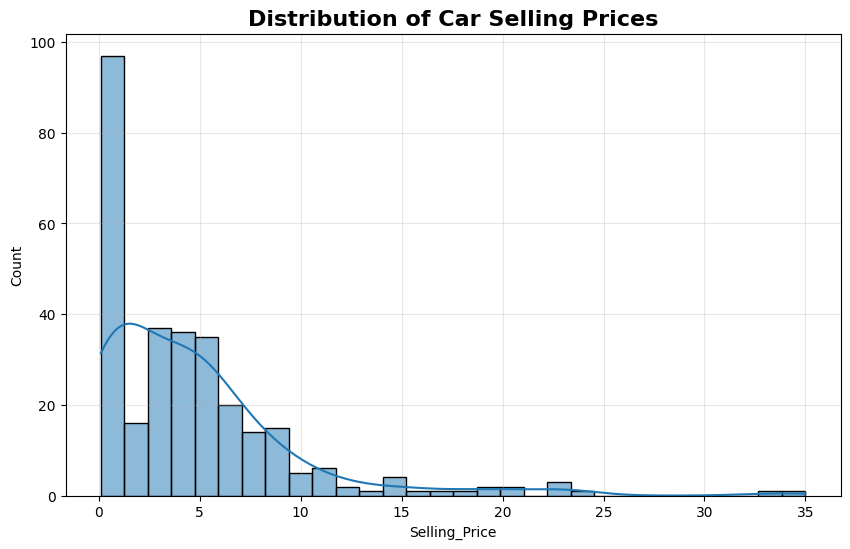

In [60]:
plt.figure(figsize=(10,6))
sns.histplot(df['Selling_Price'], kde=True, bins=30)
plt.title("Distribution of Car Selling Prices", fontsize=16, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

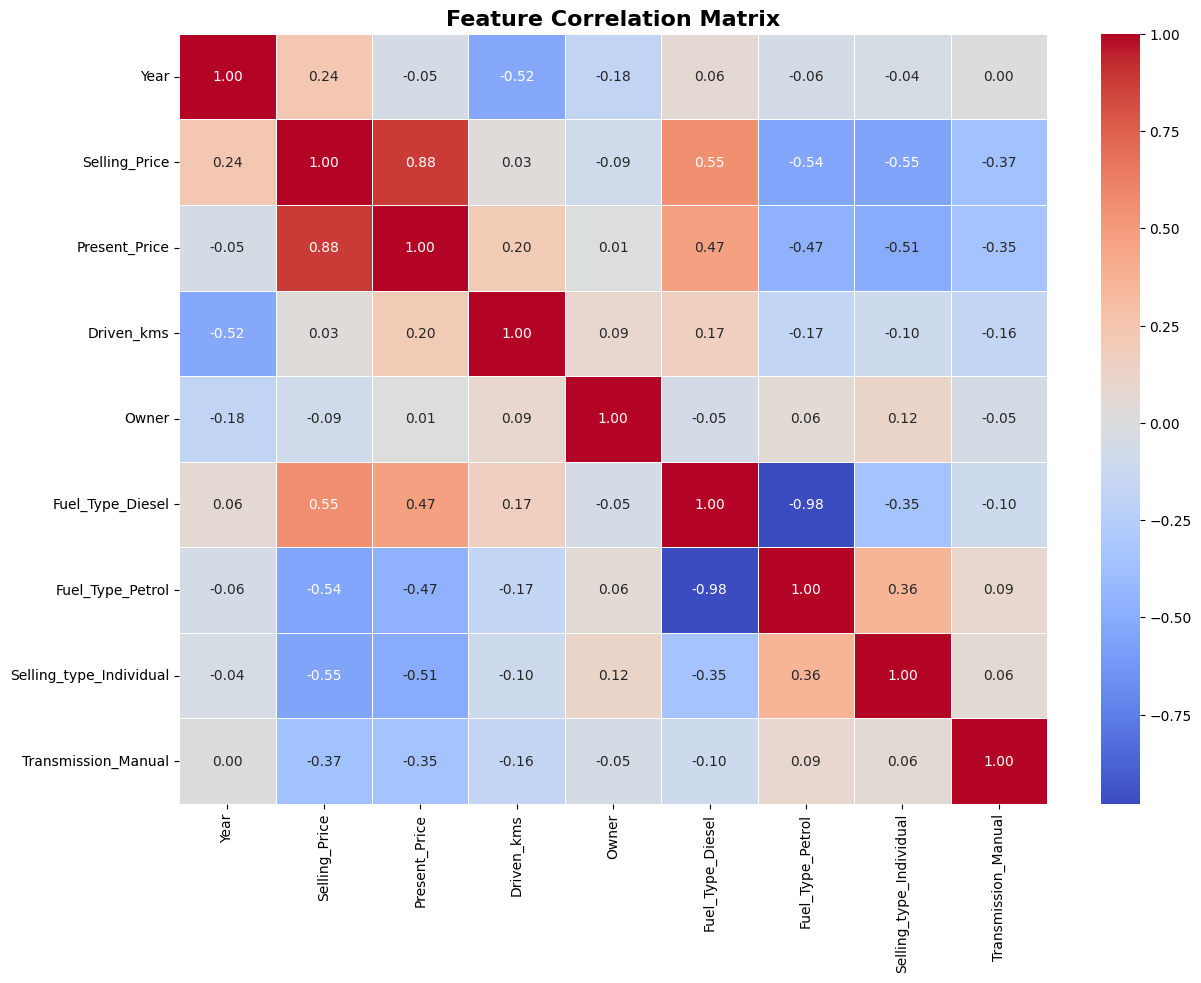

In [61]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=16, fontweight='bold')
plt.show()

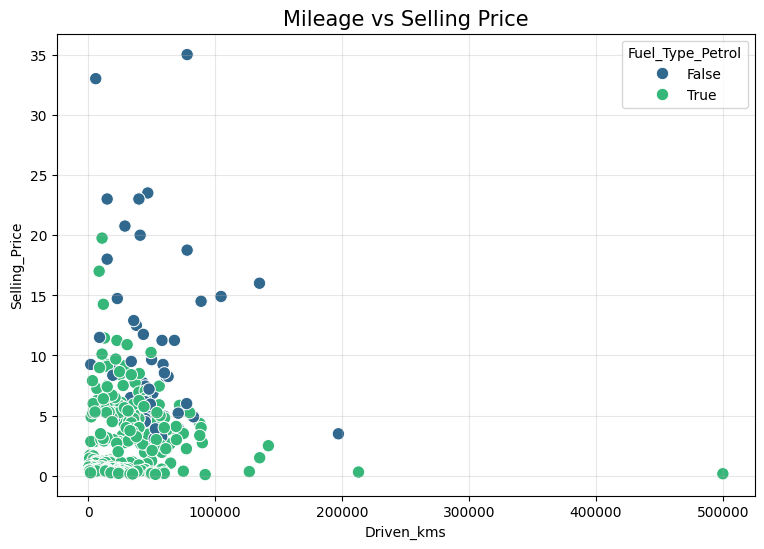

In [63]:
plt.figure(figsize=(9,6))
sns.scatterplot(
    x=df['Driven_kms'],
    y=df['Selling_Price'],
    hue=df['Fuel_Type_Petrol'],
    palette="viridis",
    s=80
)
plt.title("Mileage vs Selling Price", fontsize=15)
plt.grid(alpha=0.3)
plt.show()

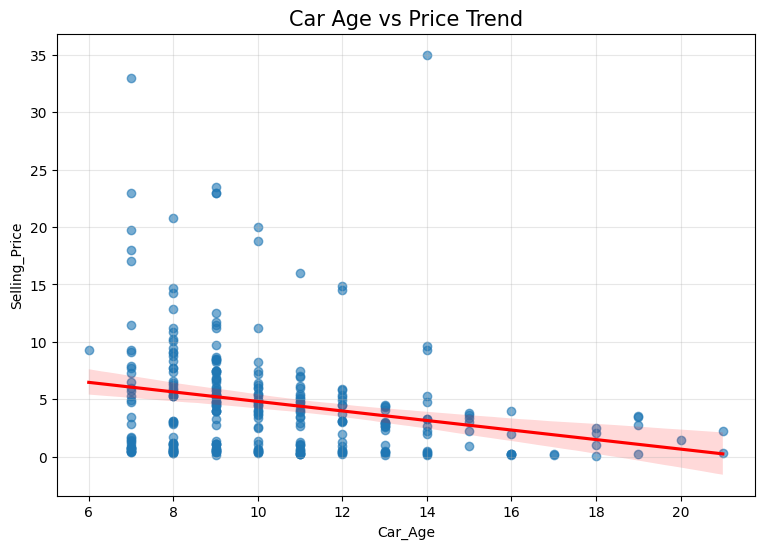

In [66]:
plt.figure(figsize=(9,6))
if 'Year' in df.columns and 'Car_Age' not in df.columns:
    df['Car_Age'] = 2024 - df['Year']
    df.drop("Year", axis=1, inplace=True)

sns.regplot(
    x=df['Car_Age'],
    y=df['Selling_Price'],
    scatter_kws={'alpha':0.6},
    line_kws={"color":"red"}
)
plt.title("Car Age vs Price Trend", fontsize=15)
plt.grid(alpha=0.3)
plt.show()

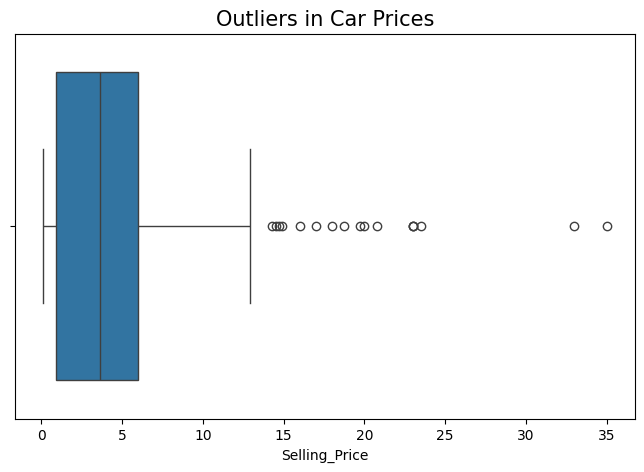

In [67]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Selling_Price'])
plt.title("Outliers in Car Prices", fontsize=15)
plt.show()

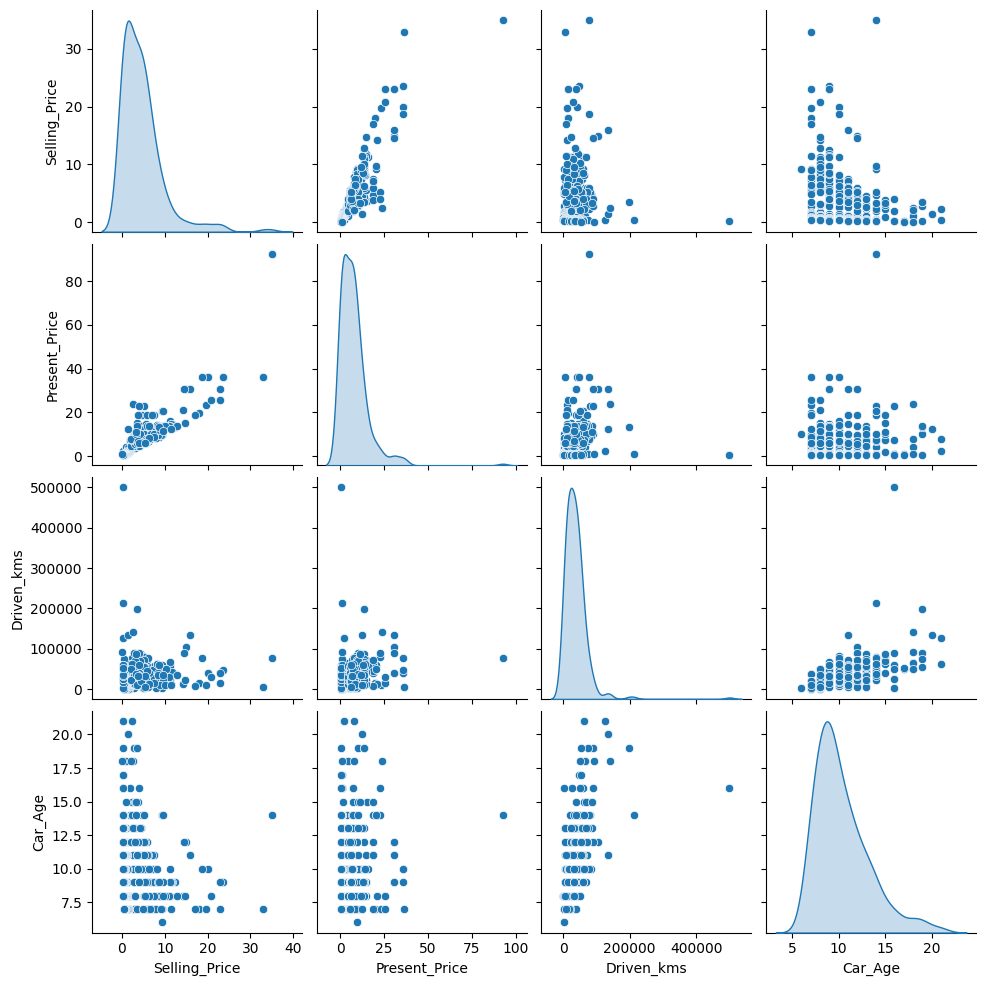

In [69]:
sns.pairplot(
    df[['Selling_Price','Present_Price','Driven_kms','Car_Age']],
    diag_kind='kde'
)
plt.show()

In [70]:
from sklearn.model_selection import train_test_split
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [44]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


In [45]:
y_pred = model.predict(X_test)

In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.2163740193330346
MSE: 3.481349830511813
R2 Score: 0.8488707839193156


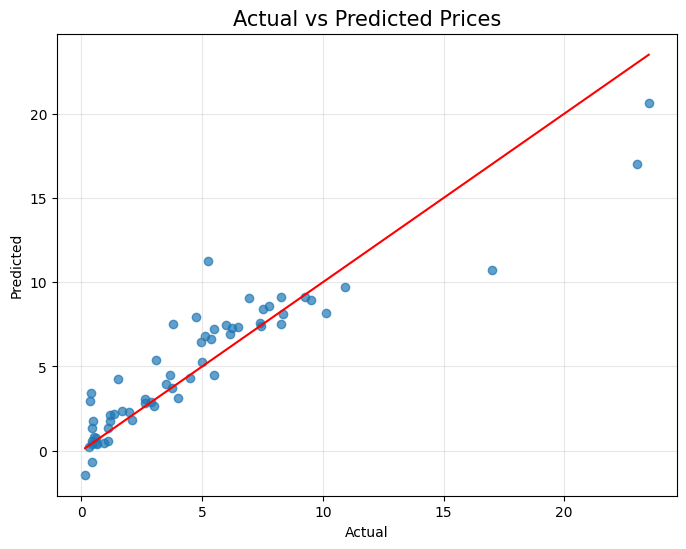

In [72]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)
plt.title("Actual vs Predicted Prices", fontsize=15)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.3)
plt.show()

In [73]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("\n Random Forest Results")
print("R2 Score:", r2_score(y_test, y_pred_rf))


 Random Forest Results
R2 Score: 0.9559328414615295


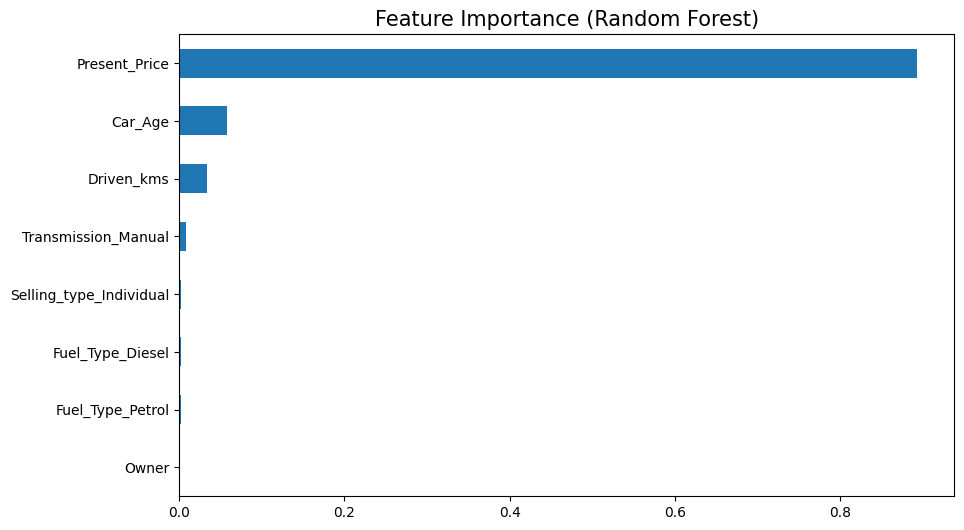

In [74]:
importance = rf.feature_importances_
features = X.columns
feat_imp = pd.Series(importance, index=features).sort_values()
plt.figure(figsize=(10,6))
feat_imp.plot(kind='barh')
plt.title("Feature Importance (Random Forest)", fontsize=15)
plt.show()

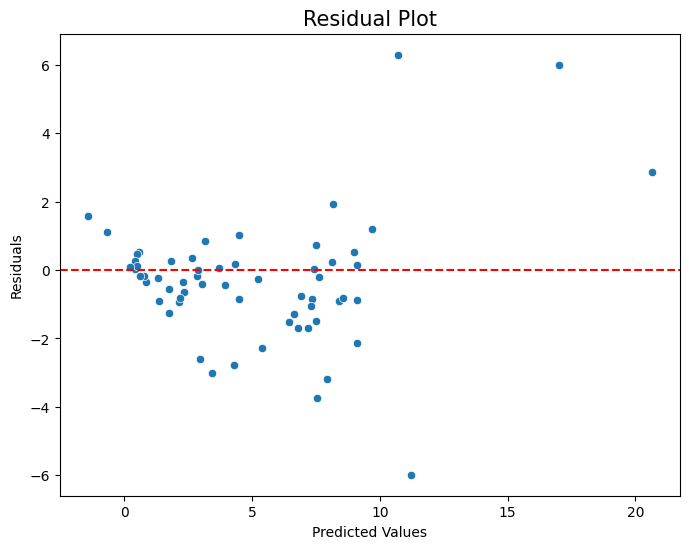

In [75]:
plt.figure(figsize=(8,6))
residuals = y_test - y_pred
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.title("Residual Plot", fontsize=15)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()